CELL 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Training notebook setup ready ✅")

Training notebook setup ready ✅


✅ CELL 2 — Define paths

In [2]:
# Project paths
PROCESSED_DIR = Path(r"D:\sign_language_project\processed")
MODELS_DIR = Path(r"D:\sign_language_project\models")
RESULTS_DIR = Path(r"D:\sign_language_project\results")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed:", PROCESSED_DIR)
print("Models:", MODELS_DIR)
print("Results:", RESULTS_DIR)

Processed: D:\sign_language_project\processed
Models: D:\sign_language_project\models
Results: D:\sign_language_project\results


✅ CELL 3 — Load extracted CSVs

In [3]:
# Load one-hand datasets
df_one_hand_train = pd.read_csv(PROCESSED_DIR / "one_hand_train.csv")
df_one_hand_val = pd.read_csv(PROCESSED_DIR / "one_hand_val.csv")

# Load two-hand datasets
df_two_hand_train = pd.read_csv(PROCESSED_DIR / "two_hand_train.csv")
df_two_hand_val = pd.read_csv(PROCESSED_DIR / "two_hand_val.csv")

print("One-Hand Train Shape:", df_one_hand_train.shape)
print("One-Hand Val Shape:", df_one_hand_val.shape)

print("Two-Hand Train Shape:", df_two_hand_train.shape)
print("Two-Hand Val Shape:", df_two_hand_val.shape)

One-Hand Train Shape: (11486, 64)
One-Hand Val Shape: (2847, 64)
Two-Hand Train Shape: (23012, 127)
Two-Hand Val Shape: (5768, 127)


✅ CELL 3 — Load extracted CSVs

In [4]:
print("One-Hand Classes:")
print(df_one_hand_train["label"].value_counts())

print("\nTwo-Hand Classes:")
print(df_two_hand_train["label"].value_counts())

One-Hand Classes:
label
V    2135
L    2025
C    1979
I    1911
U    1721
O    1715
Name: count, dtype: int64

Two-Hand Classes:
label
Y    1787
E    1785
D    1732
T    1667
K    1641
A    1534
X    1525
M    1442
G    1395
F    1265
N    1240
B    1170
S    1044
Z    1023
P     906
J     879
W     409
Q     316
R     147
H     105
Name: count, dtype: int64


✅ CELL 5 — Prepare X and y for one-hand model

In [6]:
# One-hand model data
X_one_train = df_one_hand_train.drop(columns=["label"])
y_one_train = df_one_hand_train["label"]

X_one_val = df_one_hand_val.drop(columns=["label"])
y_one_val = df_one_hand_val["label"]

print("X_one_train:", X_one_train.shape)
print("y_one_train:", y_one_train.shape)
print("X_one_val:", X_one_val.shape)
print("y_one_val:", y_one_val.shape)

X_one_train: (11486, 63)
y_one_train: (11486,)
X_one_val: (2847, 63)
y_one_val: (2847,)


✅ CELL 6 — Prepare X and y for two-hand model

In [7]:
# Two-hand model data
X_two_train = df_two_hand_train.drop(columns=["label"])
y_two_train = df_two_hand_train["label"]

X_two_val = df_two_hand_val.drop(columns=["label"])
y_two_val = df_two_hand_val["label"]

print("X_two_train:", X_two_train.shape)
print("y_two_train:", y_two_train.shape)
print("X_two_val:", X_two_val.shape)
print("y_two_val:", y_two_val.shape)

X_two_train: (23012, 126)
y_two_train: (23012,)
X_two_val: (5768, 126)
y_two_val: (5768,)


✅ CELL 7 — Train One-Hand Random Forest"

In [8]:
one_hand_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training One-Hand Random Forest...")
one_hand_rf.fit(X_one_train, y_one_train)

print("One-Hand Model Training Complete ✅")

Training One-Hand Random Forest...
One-Hand Model Training Complete ✅


✅ CELL 8 — Train Two-Hand Random Forest

In [9]:
two_hand_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Two-Hand Random Forest...")
two_hand_rf.fit(X_two_train, y_two_train)

print("Two-Hand Model Training Complete ✅")

Training Two-Hand Random Forest...
Two-Hand Model Training Complete ✅


✅ CELL 9 — One-Hand Validation Predictions

In [10]:
# One-hand predictions
y_one_pred = one_hand_rf.predict(X_one_val)

one_hand_accuracy = accuracy_score(y_one_val, y_one_pred)

print("One-Hand Validation Accuracy:", round(one_hand_accuracy * 100, 2), "%")

One-Hand Validation Accuracy: 99.65 %


✅ CELL 10 — One-Hand Classification Report

In [11]:
print("One-Hand Classification Report:\n")
print(classification_report(y_one_val, y_one_pred))

One-Hand Classification Report:

              precision    recall  f1-score   support

           C       1.00      1.00      1.00       493
           I       1.00      1.00      1.00       477
           L       1.00      1.00      1.00       519
           O       1.00      0.99      0.99       430
           U       0.99      1.00      0.99       403
           V       1.00      1.00      1.00       525

    accuracy                           1.00      2847
   macro avg       1.00      1.00      1.00      2847
weighted avg       1.00      1.00      1.00      2847



✅ CELL 11 — One-Hand Confusion Matrix

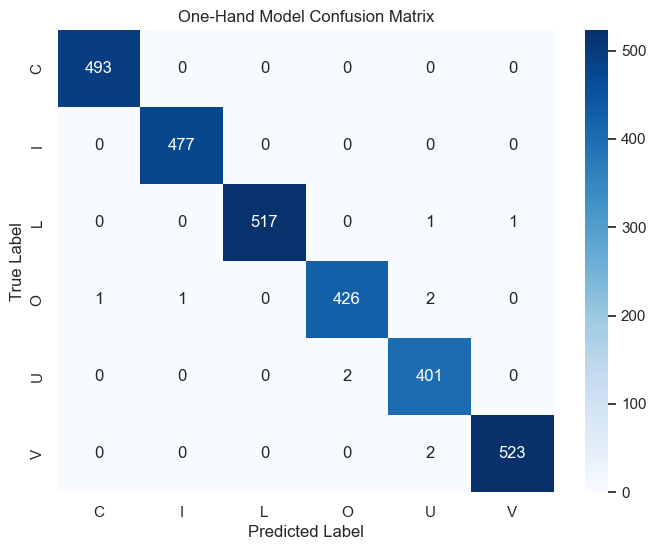

In [12]:
cm_one = confusion_matrix(y_one_val, y_one_pred, labels=sorted(y_one_val.unique()))

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_one,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_one_val.unique()),
    yticklabels=sorted(y_one_val.unique())
)
plt.title("One-Hand Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

✅ CELL 12 — Two-Hand Validation Predictions

In [13]:
# Two-hand predictions
y_two_pred = two_hand_rf.predict(X_two_val)

two_hand_accuracy = accuracy_score(y_two_val, y_two_pred)

print("Two-Hand Validation Accuracy:", round(two_hand_accuracy * 100, 2), "%")

Two-Hand Validation Accuracy: 99.86 %


✅ CELL 13 — Two-Hand Classification Report

In [14]:
print("Two-Hand Classification Report:\n")
print(classification_report(y_two_val, y_two_pred))

Two-Hand Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       397
           B       1.00      1.00      1.00       286
           D       1.00      1.00      1.00       447
           E       1.00      1.00      1.00       428
           F       0.99      1.00      1.00       309
           G       1.00      1.00      1.00       363
           H       1.00      0.96      0.98        28
           J       1.00      1.00      1.00       227
           K       1.00      1.00      1.00       411
           M       1.00      1.00      1.00       364
           N       1.00      0.99      1.00       323
           P       0.99      1.00      1.00       230
           Q       1.00      0.99      0.99        90
           R       1.00      1.00      1.00        29
           S       1.00      1.00      1.00       254
           T       1.00      1.00      1.00       426
           W       1.00      1.00      1.00     

✅ CELL 13 — Two-Hand Classification Report

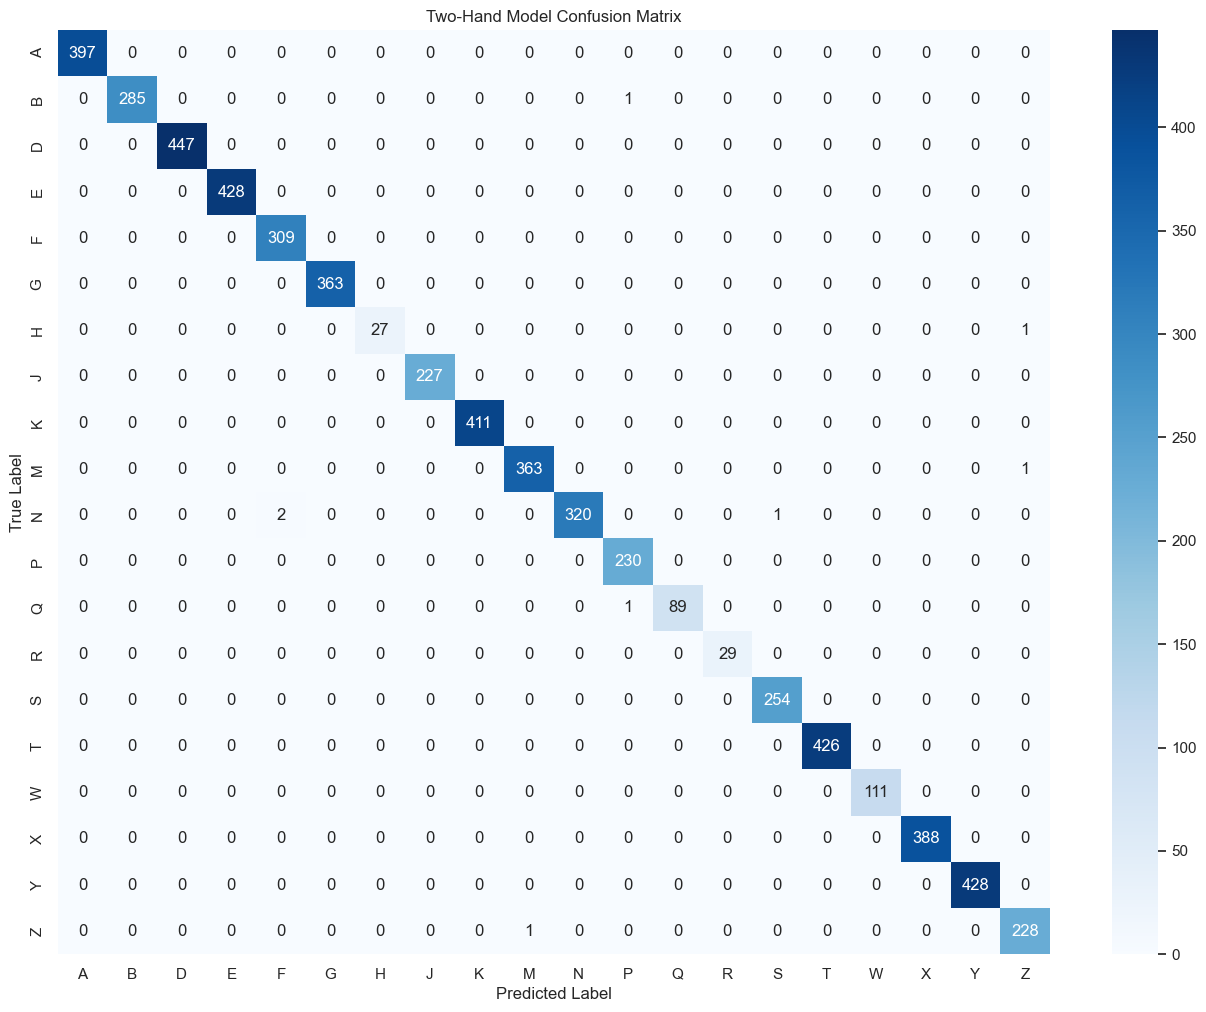

In [15]:
two_hand_labels = sorted(y_two_val.unique())
cm_two = confusion_matrix(y_two_val, y_two_pred, labels=two_hand_labels)

plt.figure(figsize=(16,12))
sns.heatmap(
    cm_two,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=two_hand_labels,
    yticklabels=two_hand_labels
)
plt.title("Two-Hand Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

✅ CELL 15 — Save trained models

In [16]:
# Save models
joblib.dump(one_hand_rf, MODELS_DIR / "one_hand_rf.pkl")
joblib.dump(two_hand_rf, MODELS_DIR / "two_hand_rf.pkl")

print("Models saved successfully ✅")
print("Saved files:")
print(MODELS_DIR / "one_hand_rf.pkl")
print(MODELS_DIR / "two_hand_rf.pkl")

Models saved successfully ✅
Saved files:
D:\sign_language_project\models\one_hand_rf.pkl
D:\sign_language_project\models\two_hand_rf.pkl
